In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandasql as psql

In [4]:
df = pd.read_csv('online_retail.csv')

print("Initial Shape:", df.shape)
print(df.head())

Initial Shape: (94230, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [5]:
# Drop missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# Remove negative or zero quantities and unit prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Compute Total Sales
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

print("Cleaned Shape:", df.shape)

Cleaned Shape: (59110, 9)


In [6]:
# We use pandasql to write SQL directly on dataframes
def q(sql): return psql.sqldf(sql, globals())
# 1. Top 10 products by revenue
query1 = """
SELECT Description, SUM(TotalSales) as revenue
FROM df
GROUP BY Description
ORDER BY revenue DESC
LIMIT 10;
"""
top_products = q(query1)
print("\nTop 10 Products by Revenue:\n", top_products)


Top 10 Products by Revenue:
                           Description   revenue
0      MEDIUM CERAMIC TOP STORAGE JAR  77183.60
1            REGENCY CAKESTAND 3 TIER  35032.65
2  WHITE HANGING HEART T-LIGHT HOLDER  28315.05
3                       CHILLI LIGHTS  14261.16
4        VINTAGE UNION JACK MEMOBOARD  13818.53
5                             POSTAGE  11559.00
6             JUMBO BAG RED RETROSPOT  11290.80
7   WOOD BLACK BOARD ANT WHITE FINISH  10338.06
8               HEART OF WICKER LARGE   9891.92
9            BLACK RECORD COVER FRAME   9167.34


In [7]:
# 2. Monthly revenue trend
query2 = """
SELECT strftime('%Y-%m', InvoiceDate) as month, SUM(TotalSales) as revenue
FROM df
GROUP BY month
ORDER BY month;
"""
monthly_sales = q(query2)
print("\nMonthly Revenue Trend:\n", monthly_sales.head())


Monthly Revenue Trend:
      month    revenue
0  2010-12  572713.89
1  2011-01  569445.04
2  2011-02  277707.49


In [8]:
# 3. Top 5 countries by revenue
query3 = """
SELECT Country, SUM(TotalSales) as revenue
FROM df
GROUP BY Country
ORDER BY revenue DESC
LIMIT 5;
"""
top_countries = q(query3)
print("\nTop Countries by Revenue:\n", top_countries)


Top Countries by Revenue:
           Country     revenue
0  United Kingdom  1163094.66
1            EIRE    39201.69
2         Germany    38473.64
3     Netherlands    36916.37
4          France    32149.10


In [10]:
# 4. Correlation between Quantity, UnitPrice, and TotalSales
corr = df[['Quantity', 'UnitPrice', 'TotalSales']].corr()
print("\nCorrelation Matrix:\n", corr)


Correlation Matrix:
             Quantity  UnitPrice  TotalSales
Quantity    1.000000  -0.012363    0.981408
UnitPrice  -0.012363   1.000000    0.024144
TotalSales  0.981408   0.024144    1.000000


In [11]:
# 5. Inventory Days Approximation (based on frequency of sales per product)
inventory_days = df.groupby('StockCode')['InvoiceDate'].agg(['min','max','count'])
inventory_days['days_active'] = (inventory_days['max'] - inventory_days['min']).dt.days + 1
inventory_days['avg_daily_sales'] = inventory_days['count'] / inventory_days['days_active']
inventory_days.reset_index(inplace=True)
print("\nInventory Days Sample:\n", inventory_days.head())


Inventory Days Sample:
   StockCode                 min                 max  count  days_active  \
0     10002 2010-12-01 08:45:00 2011-02-17 12:01:00     37           79   
1     10120 2010-12-03 11:19:00 2010-12-10 11:24:00      4            8   
2    10123C 2010-12-03 11:19:00 2010-12-03 11:19:00      1            1   
3    10124A 2010-12-06 13:13:00 2011-02-08 10:32:00      2           64   
4    10124G 2010-12-02 13:14:00 2010-12-02 13:14:00      1            1   

   avg_daily_sales  
0         0.468354  
1         0.500000  
2         1.000000  
3         0.031250  
4         1.000000  


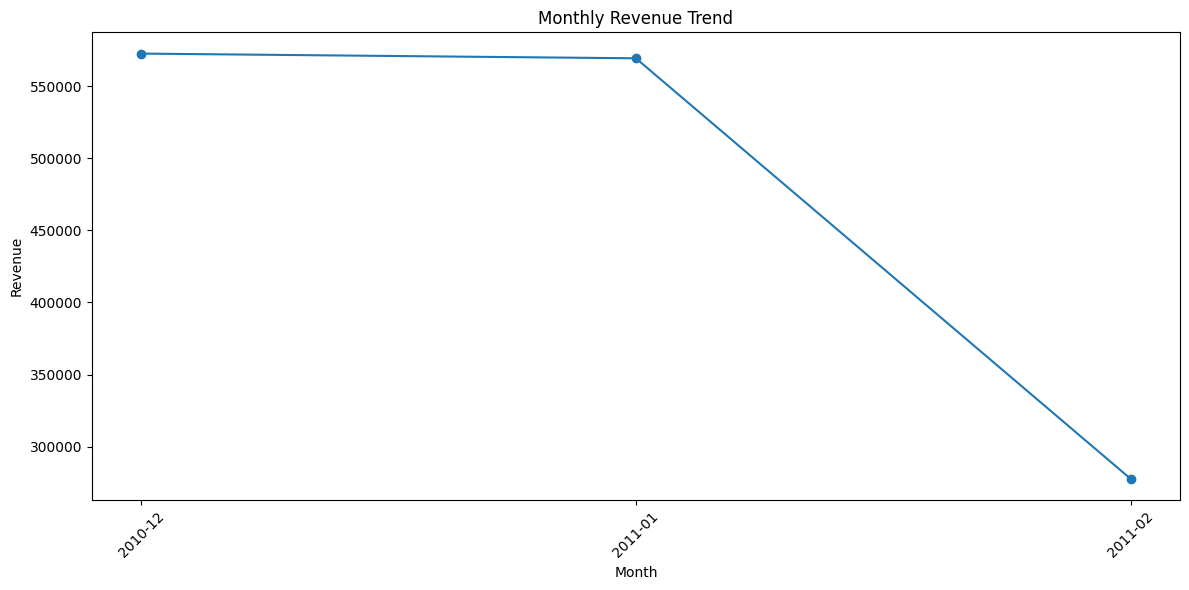

In [12]:
# 6. Monthly revenue trend plot
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['month'], monthly_sales['revenue'], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

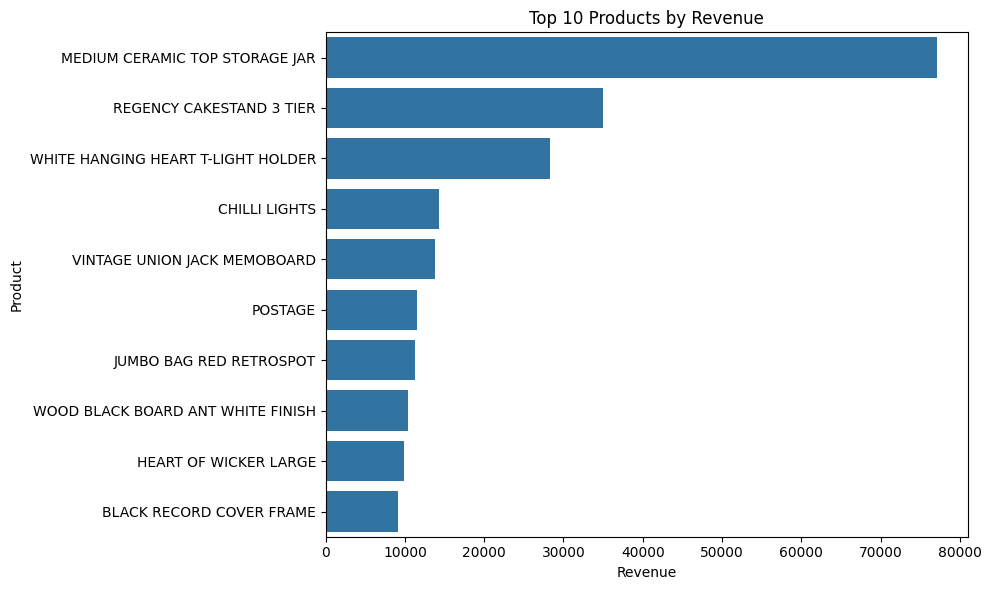

In [16]:
# 7. Top Products by Revenue (Bar Plot)
plt.figure(figsize=(10,6))
sns.barplot(x='revenue', y='Description', data=top_products)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

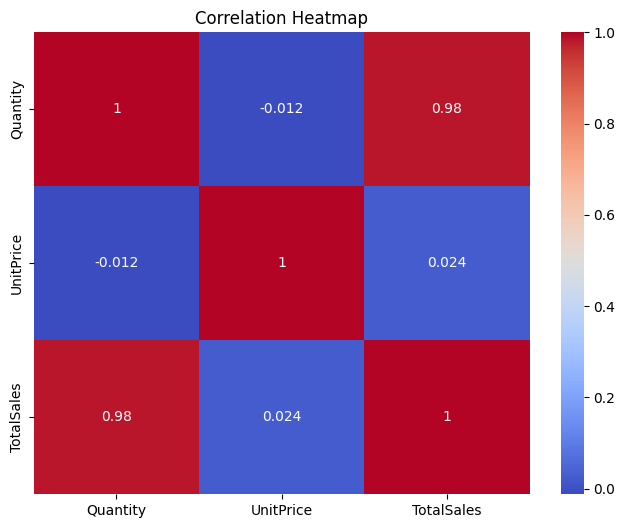

In [17]:
# 8. Heatmap of correlations
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# Export Cleaned Data
df.to_csv('cleaned_online_retail.csv', index=False)
print("\nCleaned dataset exported as cleaned_online_retail.csv")


Cleaned dataset exported as cleaned_online_retail.csv


In [19]:
# Key Insights Summary
total_revenue = df['TotalSales'].sum()
unique_products = df['Description'].nunique()
unique_customers = df['CustomerID'].nunique()
print(f"""
Key Insights:
1. Total Revenue: {total_revenue:,.2f}
2. Unique Products: {unique_products}
3. Unique Customers: {unique_customers}
4. Top Revenue Countries:
{top_countries}
""")


Key Insights:
1. Total Revenue: 1,419,866.42
2. Unique Products: 2736
3. Unique Customers: 1528
4. Top Revenue Countries:
          Country     revenue
0  United Kingdom  1163094.66
1            EIRE    39201.69
2         Germany    38473.64
3     Netherlands    36916.37
4          France    32149.10

